In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install duckdb
!{sys.executable} -m pip install pyarrow
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} pip install --upgrade pandas pyarrow



c:\Users\david\AppData\Local\Programs\Python\Python310\python.exe: can't open file 'c:\\Users\\david\\Documents\\UNI\\sem_3\\multidisciplinary project\\datasets\\pip': [Errno 2] No such file or directory


In [ ]:
import duckdb

# select the average number of likes for all the users and for users that received less than 30 likes in total

query1="""
    SELECT AVG(count) as avg_likes FROM(
    SELECT
        subject.did_id AS subject_id,
        count(*) as count
    FROM read_parquet('chunk_0_likes.parquet')
    GROUP BY subject.did_id)"""

query2="""
    SELECT AVG(count) as avg_likes FROM(
        SELECT
        subject.did_id AS subject_id,
        count(*) as count
        FROM read_parquet('chunk_0_likes.parquet')

        WHERE subject.did_id IN
        (
            SELECT did_id FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
            SELECT 
            did_id as did_id
            from (
            SELECT did_id, count(*) as count
            FROM read_parquet('chunk_0_likes.parquet') group by did_id)
            WHERE count<30)
        )
        GROUP BY subject.did_id
    )"""

result1=duckdb.query(query1)
result2=duckdb.query(query2)


print(result1)
print(result2)

┌────────────────────┐
│     avg_likes      │
│       double       │
├────────────────────┤
│ 14.869368877072697 │
└────────────────────┘

┌───────────────────┐
│     avg_likes     │
│      double       │
├───────────────────┤
│ 2.910265125764786 │
└───────────────────┘



In [ ]:
#for loop that calculates the average number of likes received setting a minimum of likes given

avg_bottom_likes=[]

query3="""
    SELECT AVG(count) as avg_likes FROM(
        SELECT
        subject.did_id AS subject_id,
        count(*) as count
        FROM read_parquet('chunk_0_likes.parquet')

        WHERE subject.did_id IN
        (
            SELECT did_id FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
            SELECT 
            did_id as did_id
            from (
            SELECT did_id, count(*) as count
            FROM read_parquet('chunk_0_likes.parquet') group by did_id)
            WHERE count<{min_likes})
        )
        GROUP BY subject.did_id
    )"""


for i in range(1,20):
    
    min_likes=i*10

    queryf= query3.format(min_likes=min_likes)
    result=duckdb.query(queryf)
    
    avg_bottom_likes.append((min_likes, result.fetchall()[0][0]))
    print(f"users that gave less than {min_likes} received on average {result.fetchall()[0][0]} likes")

users that gave less than 10 received on average 2.094910591471802 likes
users that gave less than 20 received on average 2.3200677392040645 likes
users that gave less than 30 received on average 2.910265125764786 likes
users that gave less than 40 received on average 2.9807807807807807 likes
users that gave less than 50 received on average 3.010828370330265 likes
users that gave less than 60 received on average 3.2534930139720557 likes
users that gave less than 70 received on average 3.3910226746876444 likes
users that gave less than 80 received on average 3.758377425044092 likes
users that gave less than 90 received on average 3.9251786464901217 likes
users that gave less than 100 received on average 3.9548387096774196 likes
users that gave less than 110 received on average 4.059143968871595 likes
users that gave less than 120 received on average 4.037495313085865 likes
users that gave less than 130 received on average 4.117754952311079 likes
users that gave less than 140 received on

In [ ]:
#for loop that calculates the average number of likes received setting a maximum of likes given

avg_top_likes=[]

query3="""
    SELECT AVG(count) as avg_likes FROM(
        SELECT
        subject.did_id AS subject_id,
        count(*) as count
        FROM read_parquet('chunk_0_likes.parquet')

        WHERE subject.did_id IN
        (
            SELECT did_id FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
            SELECT 
            did_id as did_id
            from (
            SELECT did_id, count(*) as count
            FROM read_parquet('chunk_0_likes.parquet') group by did_id)
            WHERE count>{max_likes})
        )
        GROUP BY subject.did_id
    )"""

for i in range(10,20):
    
    max_likes=i*5000

    queryf= query3.format(max_likes=max_likes)
    result=duckdb.query(queryf)
    
    avg_top_likes.append((max_likes, result.fetchall()[0][0]))
    print(f"users that gave more than {max_likes} received on average {result.fetchall()[0][0]} likes")

users that gave more than 50000 received on average 263.15384615384613 likes
users that gave more than 55000 received on average 296.1363636363636 likes
users that gave more than 60000 received on average 195.11111111111111 likes
users that gave more than 65000 received on average 213.07142857142858 likes
users that gave more than 70000 received on average 221.46153846153845 likes
users that gave more than 75000 received on average 270.8 likes
users that gave more than 80000 received on average 235.0 likes
users that gave more than 85000 received on average 338.8333333333333 likes
users that gave more than 90000 received on average 338.8333333333333 likes
users that gave more than 95000 received on average 338.8333333333333 likes


In [ ]:
# estimates the reduction of the file counting the number of rows before and after the filter.
# initial_rows = is the number of rows in the file
# final_rows = the number of rows after a filter (for exammple we exclude all the user giving < 30 likes)
# rows_to_delete = assuming all the users deleted from the filter have the average amount of likes, we will have to delete a number of rows 
# equal to: (initial_rows-final_rows)*avg_of_likes


query_all = """
        SELECT 
        *
        FROM read_parquet('chunk_0_likes.parquet')""" 

result1=duckdb.query(query_all)
initial_rows=len(result1)

bottom_reductions=[]

for el in avg_bottom_likes:

    query_filter = f"""
        SELECT * FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
        SELECT 
        did_id as did_id
        from (
        SELECT did_id, count(*) as count
        FROM read_parquet('chunk_0_likes.parquet') group by did_id)
        WHERE count>{el[0]}
        )""" 

    result2=duckdb.query(query_filter)

    final_rows=len(result2)
    rows_to_delete=(initial_rows-final_rows)*el[1]

    reduction_percentage= (final_rows-rows_to_delete)/initial_rows

    bottom_reductions.append((el[0], reduction_percentage))
    print(f"deleting all users giving < {el[0]} likes produces a reduction of: {reduction_percentage}")

deleting all users giving < 10 likes produces a reduction of: 0.9863861072902339
deleting all users giving < 20 likes produces a reduction of: 0.9680403639288738
deleting all users giving < 30 likes produces a reduction of: 0.9454099616587356
deleting all users giving < 40 likes produces a reduction of: 0.92842795003003
deleting all users giving < 50 likes produces a reduction of: 0.9125547166215485
deleting all users giving < 60 likes produces a reduction of: 0.8925693142714571
deleting all users giving < 70 likes produces a reduction of: 0.8741091603655714
deleting all users giving < 80 likes produces a reduction of: 0.8475732305114638
deleting all users giving < 90 likes produces a reduction of: 0.8265962802858343
deleting all users giving < 100 likes produces a reduction of: 0.8099165316129032
deleting all users giving < 110 likes produces a reduction of: 0.790815527003891
deleting all users giving < 120 likes produces a reduction of: 0.7775998712973379
deleting all users giving < 

In [ ]:
# does the same thing as above but with the max filters 
# Negative values on the reductions means that they are mainly liking eachother


top_reductions=[]

for el in avg_top_likes:

    query_filter = f"""
        SELECT * FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
        SELECT 
        did_id as did_id
        from (
        SELECT did_id, count(*) as count
        FROM read_parquet('chunk_0_likes.parquet') group by did_id)
        WHERE count<{el[0]}
        )""" 

    result2=duckdb.query(query_filter)

    final_rows=len(result2)
    rows_to_delete=(initial_rows-final_rows)*el[1]

    #print(initial_rows, final_rows, rows_to_delete)

    reduction_percentage= (final_rows-rows_to_delete)/initial_rows

    top_reductions.append((el[0], reduction_percentage))
    print(f"deleting all users with > {el[0]} likes produces a reduction of: {reduction_percentage} in the file")

deleting all users with > 50000 likes produces a reduction of: -34.79795753076923 in the file
deleting all users with > 55000 likes produces a reduction of: -36.18223314772727 in the file
deleting all users with > 60000 likes produces a reduction of: -20.74546677777778 in the file
deleting all users with > 65000 likes produces a reduction of: -20.035407821428574 in the file
deleting all users with > 70000 likes produces a reduction of: -20.114269538461535 in the file
deleting all users with > 75000 likes produces a reduction of: -21.87328823 in the file
deleting all users with > 80000 likes produces a reduction of: -17.9230818 in the file
deleting all users with > 85000 likes produces a reduction of: -22.020887716666667 in the file
deleting all users with > 90000 likes produces a reduction of: -22.020887716666667 in the file
deleting all users with > 95000 likes produces a reduction of: -22.020887716666667 in the file


In [ ]:
# since they are liking eachother we can exclude rows_to_delete from the computation

top_reductions2=[]

for el in avg_top_likes:

    query_filter = f"""
        SELECT * FROM read_parquet('chunk_0_likes.parquet') WHERE did_id IN (
        SELECT 
        did_id as did_id
        from (
        SELECT did_id, count(*) as count
        FROM read_parquet('chunk_0_likes.parquet') group by did_id)
        WHERE count<{el[0]}
        )""" 

    result2=duckdb.query(query_filter)

    final_rows=len(result2)

    #print(initial_rows, final_rows, rows_to_delete)

    reduction_percentage= (final_rows)/initial_rows

    top_reductions2.append((el[0], reduction_percentage))
    print(f"deleting all users with > {el[0]} likes produces a reduction of: {reduction_percentage} in the file")

deleting all users with > 50000 likes produces a reduction of: 0.86448065 in the file
deleting all users with > 55000 likes produces a reduction of: 0.87486475 in the file
deleting all users with > 60000 likes produces a reduction of: 0.8891166 in the file
deleting all users with > 65000 likes produces a reduction of: 0.9017365 in the file
deleting all users with > 70000 likes produces a reduction of: 0.905088 in the file
deleting all users with > 75000 likes produces a reduction of: 0.91584515 in the file
deleting all users with > 80000 likes produces a reduction of: 0.91981745 in the file
deleting all users with > 85000 likes produces a reduction of: 0.9322583 in the file
deleting all users with > 90000 likes produces a reduction of: 0.9322583 in the file
deleting all users with > 95000 likes produces a reduction of: 0.9322583 in the file


In [10]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt


file = pq.ParquetFile("likes.parquet")
df = file.read().to_pandas()


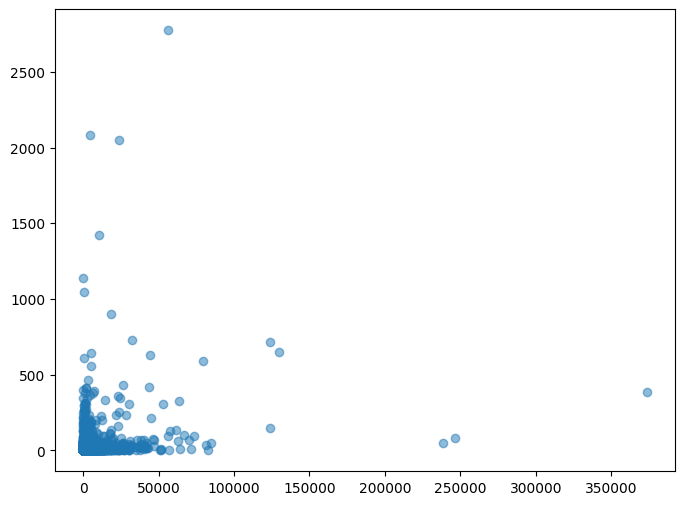

In [11]:
did_counts = df['did_id'].value_counts()
subject_counts = df['subject_id'].value_counts()

counts_df = pd.DataFrame({
    'did_count': did_counts,
    'subject_count': subject_counts
}).dropna()

plt.figure(figsize=(8, 6))
plt.scatter(counts_df['did_count'], counts_df['subject_count'], alpha=0.5)
plt.show()


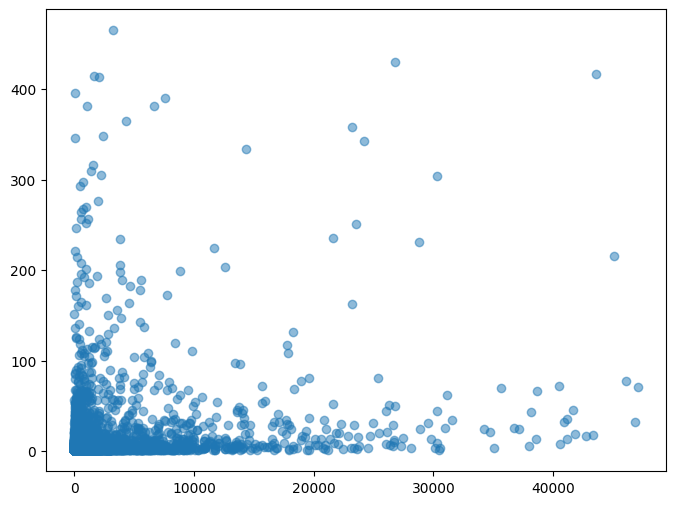

In [12]:
counts_df_filtered = counts_df[(counts_df['subject_count'] <500) & (counts_df['did_count'] < 50000)]

plt.figure(figsize=(8, 6))
plt.scatter(counts_df_filtered['did_count'], counts_df_filtered['subject_count'], alpha=0.5)
plt.show()


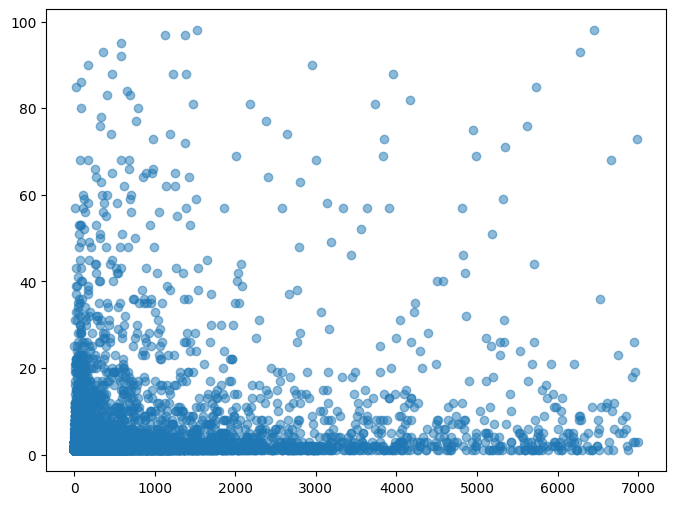

In [13]:
counts_df_filtered = counts_df[(counts_df['subject_count'] <100) & (counts_df['did_count'] < 7000)]

plt.figure(figsize=(8, 6))
plt.scatter(counts_df_filtered['did_count'], counts_df_filtered['subject_count'], alpha=0.5)
plt.show()